<a href="https://colab.research.google.com/github/pdf1802/f1-data-science/blob/main/notebooks/lap_time_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🏎️ Lap Time Prediction Model

## What this notebook does
Builds a machine learning model that predicts F1 lap times based on
tyre compound, tyre age, team, lap number and weather conditions.
We train on multiple races across multiple seasons to make the model
generalizable across different tracks and conditions.

## Why these features?
- TyreLife: older tyres = slower laps (degradation)
- Compound: SOFT/MEDIUM/HARD have different baseline pace and wear rates
- Team: car performance affects lap time independently of tyres
- LapNumber: fuel burns off as race progresses, making the car lighter = faster
- TrackTemp: hotter track = faster degradation, affects grip level
- AirTemp: affects engine and tyre performance
- Rainfall: wet conditions completely change lap time expectations

## Why weather matters
The same tyre compound at lap 10 behaves completely differently in
Bahrain (TrackTemp ~50°C) vs Silverstone (TrackTemp ~25°C, possibly wet).
Without weather our model would be confused by these differences.

## Model choice
We use XGBoost — a gradient boosting algorithm that handles:
- Non-linear relationships (degradation isn't a straight line)
- Mixed feature types (numbers + categories like compound and team)
- Noisy real-world data well
- Interactions between features (e.g. soft tyre + high track temp = extra degradation)

## Target variable
LapTimeSeconds — the lap time in seconds we want to predict

In [1]:
!pip install fastf1 pandas numpy matplotlib seaborn scikit-learn xgboost -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 135.5/135.5 kB 2.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 70.2/70.2 kB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 27.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 55.6/55.6 kB 1.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.1/73.1 kB 3.1 MB/s eta 0:00:00


## Data Loading — V2 Expanded Dataset

We train on **2022, 2023, 2024, and 2025** race sessions.

### Why 2022 as the start?
F1 introduced ground-effect aerodynamics in 2022 — a complete regulation change.
Pre-2022 data has fundamentally different car behaviour (following distances,
tyre degradation, overtake rates). Mixing it with 2022+ data would teach the
model contradictory physics. 2022–2025 = same regulation era, consistent physics.

### Why not Intermediate and Wet compounds?
Intermediates and Wets don't thermally degrade the way dry compounds do.
You're not accumulating heat stress over 20 laps — you're timing a switch
based on track water level. The degradation physics is completely different.
Including them would give the model contradictory examples and make it worse.
The `RainfallEncoded` feature already captures the effect of wet conditions
on dry-compound lap times (slower pace, safety car periods, cold tyres).

### Circuit selection — why these 8?
We need coverage of all circuit archetypes so the model generalises:
- **High-speed flowing** (Silverstone, Spa): high-load corners, high tyre stress
- **Street / technical** (Monaco, Singapore): low speed, mechanical grip, high deg
- **Power circuits** (Monza): long straights, low deg
- **Modern smooth** (Bahrain, Abu Dhabi, Japan): representative 'standard' circuits

4 seasons × 8 circuits = **32 race sessions** (~55,000–75,000 lap rows)

In [2]:
from google.colab import drive
drive.mount('/content/drive')

import os
import fastf1
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

os.makedirs('/content/drive/MyDrive/f1_cache', exist_ok=True)
os.makedirs('/content/drive/MyDrive/f1_models', exist_ok=True)

print("✅ Setup complete")


# ════════════════════════════════════════════════════════════════════════════
# REPLACE CELL 3 — SESSIONS list + correct loading loop for Module 1
#
# The previous version had Module 2's overtaking detection code
# copy-pasted here by mistake. Module 1 just needs raw laps → full_data.
# The adjacent-car pair logic belongs only in overtaking_model.ipynb.
# ════════════════════════════════════════════════════════════════════════════

CACHE_DIR = '/content/drive/MyDrive/f1_cache'
fastf1.Cache.enable_cache(CACHE_DIR)

# 4 seasons × 8 circuit archetypes = 32 race sessions
# Same universe as Module 2 — consistent training data across both models
SESSIONS = [
    (2022, 'Great Britain', 'R'), (2023, 'Great Britain', 'R'),
    (2024, 'Great Britain', 'R'), (2025, 'Great Britain', 'R'),
    (2022, 'Monaco',        'R'), (2023, 'Monaco',        'R'),
    (2024, 'Monaco',        'R'), (2025, 'Monaco',        'R'),
    (2022, 'Italy',         'R'), (2023, 'Italy',         'R'),
    (2024, 'Italy',         'R'), (2025, 'Italy',         'R'),
    (2022, 'Bahrain',       'R'), (2023, 'Bahrain',       'R'),
    (2024, 'Bahrain',       'R'), (2025, 'Bahrain',       'R'),
    (2022, 'Belgium',       'R'), (2023, 'Belgium',       'R'),
    (2024, 'Belgium',       'R'), (2025, 'Belgium',       'R'),
    (2022, 'Singapore',     'R'), (2023, 'Singapore',     'R'),
    (2024, 'Singapore',     'R'), (2025, 'Singapore',     'R'),
    (2022, 'Abu Dhabi',     'R'), (2023, 'Abu Dhabi',     'R'),
    (2024, 'Abu Dhabi',     'R'), (2025, 'Abu Dhabi',     'R'),
    (2022, 'Japan',         'R'), (2023, 'Japan',         'R'),
    (2024, 'Japan',         'R'), (2025, 'Japan',         'R'),
]

# ── Simple loading loop — all we need for Module 1 is raw laps ────────────
# No overtake detection, no adjacent-car pairs, no all_rows list.
# Just load each session, tag it with Season/Race, concatenate.
all_laps = []
failed   = []

for season, circuit, session_type in SESSIONS:
    try:
        session = fastf1.get_session(season, circuit, session_type)
        # telemetry=False → skip raw channel data, 5× faster download
        # weather=True    → we need TrackTemp, AirTemp, Rainfall
        session.load(telemetry=False, weather=True)

        laps = session.laps.copy()
        laps['Season'] = season
        laps['Race']   = circuit

        # Attach session-level weather to every lap row
        # Using session median — lap-level weather is too noisy
        weather = session.weather_data
        if weather is not None and len(weather) > 0:
            laps['TrackTemp'] = weather['TrackTemp'].median()
            laps['AirTemp']   = weather['AirTemp'].median()
            laps['Rainfall']  = int(weather['Rainfall'].any())
        else:
            laps['TrackTemp'] = 30.0
            laps['AirTemp']   = 25.0
            laps['Rainfall']  = 0

        all_laps.append(laps)
        print(f"  ✅ {season} {circuit:<15} — {len(laps)} laps")

    except Exception as e:
        print(f"  ❌ {season} {circuit:<15} — FAILED: {e}")
        failed.append((season, circuit))

full_data = pd.concat(all_laps, ignore_index=True)

print(f"\n{'='*50}")
print(f"Total laps loaded  : {len(full_data):,}")
print(f"Sessions succeeded : {len(SESSIONS) - len(failed)} / {len(SESSIONS)}")
if failed:
    print(f"Failed sessions    : {failed}")
print(f"Seasons in data    : {sorted(full_data['Season'].unique())}")



Mounted at /content/drive
✅ Setup complete


core           INFO 	Loading data for British Grand Prix - Race [v3.8.1]
INFO:fastf1.fastf1.core:Loading data for British Grand Prix - Race [v3.8.1]
req            INFO 	No cached data found for session_info. Loading data...
INFO:fastf1.fastf1.req:No cached data found for session_info. Loading data...
_api           INFO 	Fetching session info data...
INFO:fastf1.api:Fetching session info data...
DEBUG:fastf1.api:Falling back to livetiming mirror (https://livetiming-mirror.fastf1.dev)
req            INFO 	Data has been written to cache!
INFO:fastf1.fastf1.req:Data has been written to cache!
req            INFO 	No cached data found for driver_info. Loading data...
INFO:fastf1.fastf1.req:No cached data found for driver_info. Loading data...
_api           INFO 	Fetching driver list...
INFO:fastf1.api:Fetching driver list...
DEBUG:fastf1.api:Falling back to livetiming mirror (https://livetiming-mirror.fastf1.dev)
req            INFO 	Data has been written to cache!
INFO:fastf1.fastf1.req

  ✅ 2022 Great Britain   — 815 laps


req            INFO 	Data has been written to cache!
INFO:fastf1.fastf1.req:Data has been written to cache!
req            INFO 	No cached data found for driver_info. Loading data...
INFO:fastf1.fastf1.req:No cached data found for driver_info. Loading data...
_api           INFO 	Fetching driver list...
INFO:fastf1.api:Fetching driver list...
req            INFO 	Data has been written to cache!
INFO:fastf1.fastf1.req:Data has been written to cache!
DEBUG:fastf1.ergast:Failed to parse timestamp '' in Ergastresponse.
req            INFO 	No cached data found for session_status_data. Loading data...
INFO:fastf1.fastf1.req:No cached data found for session_status_data. Loading data...
_api           INFO 	Fetching session status data...
INFO:fastf1.api:Fetching session status data...
req            INFO 	Data has been written to cache!
INFO:fastf1.fastf1.req:Data has been written to cache!
req            INFO 	No cached data found for lap_count. Loading data...
INFO:fastf1.fastf1.req:No cac

  ✅ 2023 Great Britain   — 971 laps


...

  ✅ 2023 Japan           — 880 laps


req            INFO 	Using cached data for session_info
INFO:fastf1.fastf1.req:Using cached data for session_info
req            INFO 	Using cached data for driver_info
INFO:fastf1.fastf1.req:Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
INFO:fastf1.fastf1.req:Using cached data for session_status_data
req            INFO 	Using cached data for lap_count
INFO:fastf1.fastf1.req:Using cached data for lap_count
req            INFO 	Using cached data for track_status_data
INFO:fastf1.fastf1.req:Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
INFO:fastf1.fastf1.req:Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
INFO:fastf1.fastf1.req:Using cached data for timing_app_data
core           INFO 	Processing timing data...
INFO:fastf1.fastf1.core:Processing timing data...
req            INFO 	Using cached data for weather_data
INFO:fast

  ✅ 2024 Japan           — 907 laps


req            INFO 	Data has been written to cache!
INFO:fastf1.fastf1.req:Data has been written to cache!
req            INFO 	No cached data found for driver_info. Loading data...
INFO:fastf1.fastf1.req:No cached data found for driver_info. Loading data...
_api           INFO 	Fetching driver list...
INFO:fastf1.api:Fetching driver list...
req            INFO 	Data has been written to cache!
INFO:fastf1.fastf1.req:Data has been written to cache!
req            INFO 	No cached data found for session_status_data. Loading data...
INFO:fastf1.fastf1.req:No cached data found for session_status_data. Loading data...
_api           INFO 	Fetching session status data...
INFO:fastf1.api:Fetching session status data...
req            INFO 	Data has been written to cache!
INFO:fastf1.fastf1.req:Data has been written to cache!
req            INFO 	No cached data found for lap_count. Loading data...
INFO:fastf1.fastf1.req:No cached data found for lap_count. Loading data...
_api           INFO 	F

  ✅ 2025 Japan           — 1059 laps

Total laps loaded  : 33,609
Sessions succeeded : 32 / 32
Seasons in data    : [np.int64(2022), np.int64(2023), np.int64(2024), np.int64(2025)]


##Data Cleaning

We remove noisy laps before training the model:
- Lap times under 60s or over 130s are errors or anomalies
- First lap on a tyre (TyreLife=1) is always slow duw to the out lap
- TrackStatus != '1' means safety car, yellow flag or red flag - not reprsentative
- Unknown compounds (INTERMEDIATE,WET) sre excluded for now

What remains is only clean, green flag racing laps across all 10 races.

In [3]:
#Convert lap time to seconds
full_data['LapTimeSeconds'] = full_data['LapTime'].dt.total_seconds()

#Clean the data
clean_data= full_data[
    (full_data['LapTimeSeconds']>60) &        # no unrealistic fast laps
    (full_data['LapTimeSeconds']<130) &       # no unrealistic slow laps
    (full_data['TyreLife']>1) &               # remove first lap on tyre
    (full_data['TrackStatus']=='1') &         # green flag laps only
    (full_data['Compound'].isin(['SOFT', 'MEDIUM', 'HARD']))  # known compounds only
][['Driver', 'Team', 'LapNumber', 'LapTimeSeconds',
   'Compound', 'TyreLife', 'Stint',
   'TrackTemp', 'AirTemp', 'Rainfall',
   'Season', 'Race']
].copy()


clean_data=clean_data.dropna()

print(f"Laps before cleaning: {len(full_data)}")
print(f"Laps after cleaning: {len(clean_data)}")
print(f"\nCompound distribution:\n{clean_data['Compound'].value_counts()}")
print(f"\nRaces included:\n{clean_data.groupby(['Season','Race']).size()}")

Laps before cleaning: 33609
Laps after cleaning: 28037

Compound distribution:
Compound
HARD      13637
MEDIUM    10981
SOFT       3419
Name: count, dtype: int64

Races included:
Season  Race         
2022    Abu Dhabi        1049
        Bahrain           915
        Belgium           668
        Great Britain     671
        Italy             777
        Monaco            509
        Singapore         276
2023    Abu Dhabi        1106
        Bahrain           941
        Belgium           704
        Great Britain     818
        Italy             927
        Japan             719
        Monaco            976
        Singapore         841
2024    Abu Dhabi         914
        Bahrain          1047
        Belgium           766
        Great Britain    1303
        Italy             970
        Japan             798
        Monaco           1180
        Singapore        1139
2025    Abu Dhabi        1115
        Bahrain          1009
        Belgium           543
        Great Brita

## Feature Engineering

XGBoost can't read text like "SOFT" or "Ferrari" directly.
We need to convert categorical features into numbers.
This is called encoding.

- Compound: SOFT=0, MEDIUM=1, HARD=2 (ordered by speed)
- Team: label encoded (each team gets a unique number)
- Rainfall: True/False becomes 1/0

In [4]:
from sklearn.preprocessing import LabelEncoder

# Encode copound with maningful order (soft=0 fastest, hard=2 slowest)
compound_map= {'SOFT': 0, 'MEDIUM': 1, 'HARD': 2}
clean_data['CompoundEncoded'] = clean_data['Compound'].map(compound_map)

#Encode team
le=LabelEncoder()
clean_data['TeamEncoded'] = le.fit_transform(clean_data['Team'])

#Encoded rainfall
clean_data['RainfallEncoded'] =clean_data['Rainfall'].astype(int)

# Drop BaseLap if it already exists from a previous run
if 'BaseLap' in clean_data.columns:
    clean_data = clean_data.drop(columns=['BaseLap'])
if 'LapDelta' in clean_data.columns:
    clean_data = clean_data.drop(columns=['LapDelta'])

#Calculate each driver's baseline pace per race
baseline=clean_data.groupby(['Driver','Season','Race'])['LapTimeSeconds'].min()
baseline.name= 'BaseLap'
clean_data=clean_data.join(baseline,on=['Driver','Season','Race'])

#Target becomes the delta from their personal best
clean_data['LapDelta'] = clean_data['LapTimeSeconds'] - clean_data['BaseLap']

# Cap delta — more than 5s off baseline = something unusual happening
clean_data = clean_data[clean_data['LapDelta'] <= 5].copy()
clean_data = clean_data[clean_data['LapDelta'] >= 0].copy()

# Approximate fuel load — F1 cars start with ~110kg, burn ~1.8kg per lap
clean_data['FuelLoad'] = 110 - (clean_data['LapNumber'] * 1.8)

print(f"Laps after delta filter: {len(clean_data)}")
print(f"Delta range: {clean_data['LapDelta'].min():.2f}s to {clean_data['LapDelta'].max():.2f}s")

features = ['CompoundEncoded', 'TyreLife', 'TeamEncoded',
            'LapNumber', 'TrackTemp', 'AirTemp', 'RainfallEncoded',
            ]

X = clean_data[features]
y = clean_data['LapDelta']


print("Feature matrix shape:",X.shape)
print("\nSample:")
print(X.head())



Laps after delta filter: 26274
Delta range: 0.00s to 5.00s
Feature matrix shape: (26274, 7)

Sample:
   CompoundEncoded  TyreLife  TeamEncoded  LapNumber  TrackTemp  AirTemp  \
3                1       3.0           11        4.0       30.0     18.3   
4                1       4.0           11        5.0       30.0     18.3   
5                1       5.0           11        6.0       30.0     18.3   
6                1       6.0           11        7.0       30.0     18.3   
7                1       7.0           11        8.0       30.0     18.3   

   RainfallEncoded  
3                1  
4                1  
5                1  
6                1  
7                1  


## Train / Test Split

We split the data into two sets:
- 80% training — the model learns from this
- 20% testing — we use this to evaluate how well it learned

The model never sees the test set during training, so it's
a fair way to measure real performance.

random_state=42 just means the split is reproducible —
anyone running this notebook gets the same split.

In [5]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Training samples: {len(X_train)}")
print(f"Testing samples:  {len(X_test)}")

Training samples: 21019
Testing samples:  5255


## Training the XGBoost Model

XGBoost (Extreme Gradient Boosting) builds hundreds of small decision trees, each one learning from the mistakes of the previous one.
The result is a very accurate mode for tbaular data like ours.

Key parameters:
- n_estimators=500: builds 500 trees
- learning_rate=0.05: each tree contributes a small amount (more stable)
- max_depth=6: how complex each tree can be
- rando_state=42 : reproducible results

In [6]:
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, r2_score

#Train the model
model= XGBRegressor(n_estimators=500,
                    learning_rate=0.05,
                    max_depth=6,
                    random_state=42,
                    n_jobs=-1 #use all CPU cores
                    )

model.fit(X_train,y_train)

#Evaluate on test set
y_pred= model.predict(X_test)

mae= mean_absolute_error(y_test,y_pred)
r2= r2_score(y_test,y_pred)

print(f"Mean Absolute Error: {mae:.2f} seconds")
print(f"R² Score: {r2:.4f}")

Mean Absolute Error: 0.51 seconds
R² Score: 0.6555


## Model Evaluation

MAE (Mean Absolute Error) — average difference between
predicted and real lap times in seconds. Lower is better.

R² Score — how much of the variance in lap times the model
explains. 1.0 = perfect, 0.0 = learned nothing.

The scatter plot below shows predicted vs actual lap times.
A perfect model would have all dots on the diagonal line.

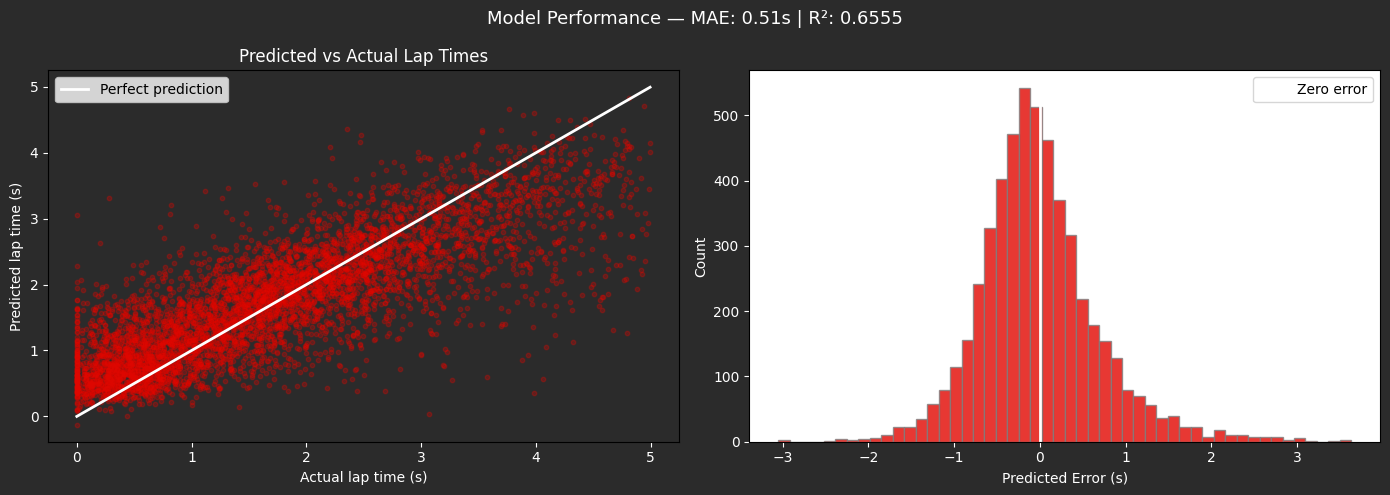

In [7]:
fig, axes= plt.subplots(1,2,figsize=(14,5))

#Plot 1- Predicted vs Actual
axes[0].scatter(y_test,y_pred,alpha=0.3,s=10,color='#E10600')
axes[0].plot([y_test.min(),y_test.max()],
             [y_test.min(),y_test.max()],
             color='white',linewidth=2, label='Perfect prediction'
             )
axes[0].set_xlabel('Actual lap time (s)',color='white')
axes[0].set_ylabel('Predicted lap time (s)',color='white')
axes[0].set_title('Predicted vs Actual Lap Times',color='white')
axes[0].legend()
axes[0].tick_params(colors='white')
axes[0].set_facecolor('#2b2b2b')

#Plot 2 - Error distrribution
errors= y_test-y_pred
axes[1].hist(errors,bins=50,color='#E10600',edgecolor='gray',alpha=0.8)
axes[1].axvline(0,color='white',linewidth=2,label='Zero error')
axes[1].set_xlabel('Predicted Error (s)',color='white')
axes[1].set_ylabel('Count',color='white')
axes[1].legend()
axes[1].tick_params(colors='white')
axes[0].set_facecolor('#2b2b2b')



fig.patch.set_facecolor('#2b2b2b')
plt.suptitle(f'Model Performance — MAE: {mae:.2f}s | R²: {r2:.4f}',
             color='white', fontsize=13)
plt.tight_layout()
plt.show()

## Feature Importance

XGBoost tells us which features it relied on most.
This validates our feature choices and tells us if
anything unexpected is driving predictions.

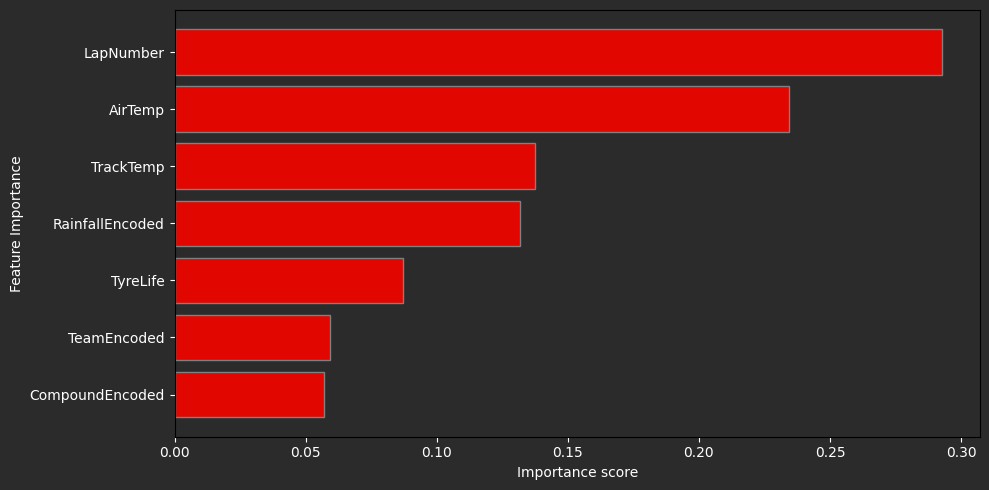

In [8]:
fig, ax= plt.subplots(figsize=(10,5))

importance= model.feature_importances_
feature_names= features

#Sort by importance
sorted_idx = importance.argsort()

ax.barh([feature_names[i] for i in sorted_idx],
        importance[sorted_idx],
        color='#E10600', edgecolor='gray')

ax.set_xlabel('Importance score',color='white')
ax.set_ylabel('Feature Importance',color='white')
ax.tick_params(colors='white')
ax.set_facecolor('#2b2b2b')
fig.patch.set_facecolor('#2b2b2b')
plt.tight_layout()
plt.show()

## Saving the Model

We save three things to Google Drive:
- lap_time_model.pkl: the trained XGBoost model
- team_encoder.pkl: the LabelEncoder for team names
- compound_map.json: the compound to number mapping

We save these separately because when we use the model
later (in the strategy recommender or simulator) we need
to encode inputs the exact same way the model was trained on.
joblib is the standard way to save/load sklearn and XGBoost models.

In [9]:
import joblib
import os


os.makedirs('/content/drive/MyDrive/f1_models',exist_ok=True)

#Save model
joblib.dump(model, '/content/drive/MyDrive/f1_models/lap_time_model.pkl')

#Save the label encoder so we can use it later
joblib.dump(le, '/content/drive/MyDrive/f1_models/team_encoder.pkl')

#Save the compound map
import json
with open('/content/drive/MyDrive/f1_models/compound_map.json', 'w') as f:
    json.dump(compound_map, f)

print("Model saved succesfuly!")


Model saved succesfuly!


## Testing the Model — Single Lap Prediction

Before building the strategy recommender we verify the model
works correctly by making one manual prediction.

We ask: "How much slower than his personal best will Leclerc be
on lap 30, Medium tyre age 15, in Bahrain conditions?"

The model returns a delta in seconds above his personal best.
A result around 1-2 seconds is realistic for a 15 lap old tyre.

In [10]:
# Predict lap delta for: Leclerc, Ferrari, Lap 30, Medium tyre age 15, Bahrain conditions
test_lap = pd.DataFrame([{
    'CompoundEncoded': compound_map['MEDIUM'],
    'TyreLife': 15,
    'TeamEncoded': le.transform(['Ferrari'])[0],
    'LapNumber': 30,
    'TrackTemp': 38,
    'AirTemp': 28,
    'RainfallEncoded': 0
}])

predicted_delta = model.predict(test_lap)[0]
print(f"Predicted delta from personal best: +{predicted_delta:.2f} seconds")

Predicted delta from personal best: +1.66 seconds


## Strategy Recommender

Uses the trained model to simulate two strategies lap by lap
and recommends the fastest one based on total predicted race time.

How it works:
1. For each strategy, simulate every remaining lap
2. Predict the delta for each lap using the model
3. Add deltas together to get total time cost
4. Compare strategies — lowest total time wins

In [11]:
def simulate_strategy(model,le,compound_map,strategy,
                      current_lap, total_laps,track_temp,
                      air_temp,rainfall=0):
  """
  Simulte a pit stop strategy from current lap to end of race.

  strategy: list of dicts, each describing a stint
  Example: [
    {'compound':'MEDIUM', 'start_lap': 31, 'end_lap': 57}
  ]
  """

  total_delta=0
  lap_by_lap=[]

  for stint in strategy:
    compound= stint['compound']
    start_lap= stint['start_lap']
    end_lap= stint['end_lap']

    for lap in range(start_lap,end_lap+1):
      tyre_age= lap- start_lap +1

      lap_input = pd.DataFrame([{
                'CompoundEncoded': compound_map[compound],
                'TyreLife': tyre_age,
                'TeamEncoded': le.transform(['Ferrari'])[0],
                'LapNumber': lap,
                'TrackTemp': track_temp,
                'AirTemp': air_temp,
                'RainfallEncoded': rainfall
            }])


      delta = model.predict(lap_input)[0]
      total_delta += delta
      lap_by_lap.append({
                'Lap': lap,
                'Compound': compound,
                'TyreAge': tyre_age,
                'PredictedDelta': round(delta, 3)
      })

  return total_delta, pd.DataFrame(lap_by_lap)

# --- SCENARIO: Leclerc, Bahrain, Lap 30, currently on Medium age 15 ---
# Option A: Pit NOW, switch to Hard, run to end (lap 57)
strategy_a = [{'compound': 'HARD', 'start_lap': 31, 'end_lap': 57}]

# Option B: Stay out 5 more laps on Medium, then pit for Hard
strategy_b = [
    {'compound': 'MEDIUM', 'start_lap': 31, 'end_lap': 35},
    {'compound': 'HARD',   'start_lap': 36, 'end_lap': 57}
]

total_a, laps_a = simulate_strategy(
    model, le, compound_map, strategy_a,
    current_lap=30, total_laps=57,
    track_temp=38, air_temp=28
)

total_b, laps_b = simulate_strategy(
    model, le, compound_map, strategy_b,
    current_lap=30, total_laps=57,
    track_temp=38, air_temp=28
)

print(f"Option A (Pit now → Hard): total delta = +{total_a:.2f}s")
print(f"Option B (Stay 5 laps → Hard): total delta = +{total_b:.2f}s")
print()

if total_a < total_b:
    print(f" Recommendation: PIT NOW — saves {total_b - total_a:.2f} seconds")
else:
    print(f" Recommendation: STAY OUT — saves {total_a - total_b:.2f} seconds")

Option A (Pit now → Hard): total delta = +14.27s
Option B (Stay 5 laps → Hard): total delta = +12.28s

 Recommendation: STAY OUT — saves 1.98 seconds


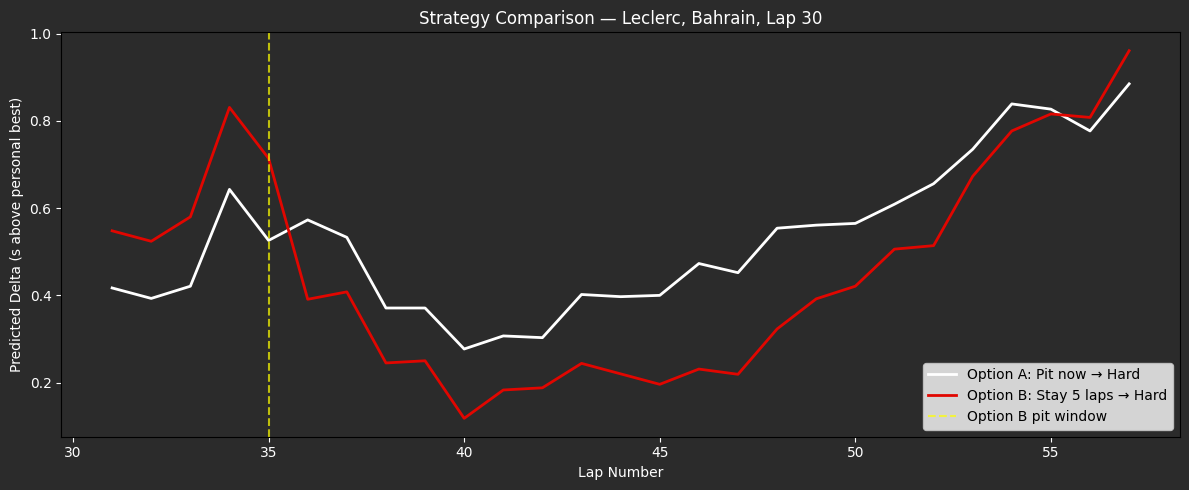

In [12]:
fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(laps_a['Lap'], laps_a['PredictedDelta'],
        color='#FFFFFF', label='Option A: Pit now → Hard', linewidth=2)
ax.plot(laps_b['Lap'], laps_b['PredictedDelta'],
        color='#E10600', label='Option B: Stay 5 laps → Hard', linewidth=2)

ax.axvline(x=35, color='yellow', linestyle='--', alpha=0.7, label='Option B pit window')
ax.set_xlabel('Lap Number', color='white')
ax.set_ylabel('Predicted Delta (s above personal best)', color='white')
ax.set_title('Strategy Comparison — Leclerc, Bahrain, Lap 30', color='white')
ax.legend()
ax.tick_params(colors='white')
ax.set_facecolor('#2b2b2b')
fig.patch.set_facecolor('#2b2b2b')
plt.tight_layout()
plt.show()

## SHAP Explainability

SHAP (SHapley Additive exPlanationes) tells us WHY he model made each individual prediction - not just which features matter globally, but how each feature pushed a specific prediction up or down.

Example: for a particular lap the model might say:
- TyreLife=20 pushed the delta UP by +0.3s (old tyre)
- LapNumber=50 pushed it DOWN by -0.2s (light fuel load)
- TrackTemp=45 pushed it UP by +0.1s (hot track)

This is what separates a trusted model from a black box.
Real F1 engineers need to understand WHY, not just WHAT.

In [13]:
!pip install shap -q



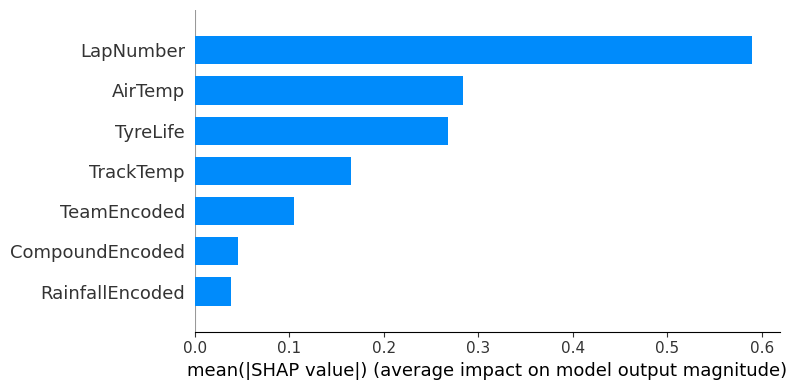

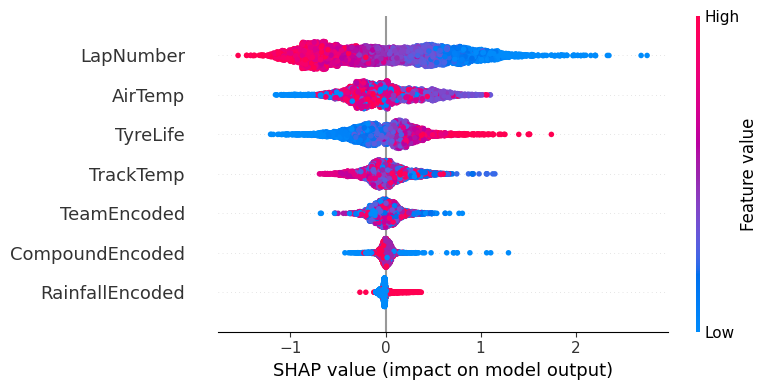

In [14]:
import shap

# Explain the model
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)

# Plot 1 — Global feature importance via SHAP
fig, ax = plt.subplots(figsize=(8, 4))
shap.summary_plot(shap_values, X_test,
                  feature_names=features,
                  plot_type="bar",
                  show=False,
                  plot_size=(8, 4))
plt.tight_layout()
plt.show()

# Plot 2 — How each feature affects predictions
shap.summary_plot(shap_values, X_test,
                  feature_names=features,
                  show=False,
                  plot_size=(8, 4))
plt.tight_layout()
plt.show()

## Understanding the SHAP Chart

Each dot is one lap from the test set. The X axis shows how much
that feature pushed the predicted delta up (right) or down (left).
Color shows the feature value: red = high, blue = low.

**LapNumber** — biggest impact. Low lap numbers (blue, early race, heavy
fuel) push delta UP by up to +3s. High lap numbers (red, late race,
light car) push delta DOWN. The model correctly learned fuel burn.

**TyreLife** — second most important. Fresh tyres (blue) cluster near 0.
Old tyres (red) push delta UP — older tyre = slower lap.
Exactly what tyre degradation looks like.

**TrackTemp** — hot track (red) pushes delta slightly UP, cold track (blue)
pushes it DOWN. Hot conditions wear tyres faster = more time loss.

**TeamEncoded** — spread both ways. Fast teams (low number, blue = Red Bull)
pull delta DOWN. Slower teams (red) push it UP.

**AirTemp** — similar to TrackTemp but smaller effect.
Hot air slightly increases lap time delta.

**CompoundEncoded** — Soft (blue, value=0) pushes delta DOWN because
softs are the fastest tyre. Hard (red, value=2) pushes it UP.

**RainfallEncoded** — almost no spread because we have very
few wet laps in the dataset. Not enough data to learn from.

Key takeaway: the model learned real F1 physics — fuel load,
tyre degradation, compound speed, and track conditions all
behave exactly as expected.

## Real Race Validation — Miami GP 2024

We test our strategy recommender against a real race to see
if it would have made the same decision as the actual F1 team.

We look at Leclerc's race — he ran an aggressive strategy
that ultimately decided his final position.

If our model agrees with the real decision, it validates
that the model has learned real F1 strategy logic.

In [15]:
#Load Miami 2024
miami=fastf1.get_session(2024,'Miami','R')
miami.load(weather=True)

miami_laps= miami.laps
miami_laps['LapTimeSeconds'] = miami.laps['LapTime'].dt.total_seconds()

#Get Leclerc's racee
lec=miami_laps.pick_driver('LEC')

#Show his stints
print("Leclerc's stints in Miami 2024:")
print(lec[['LapNumber', 'Compound', 'TyreLife',
           'LapTimeSeconds', 'Position']].dropna().to_string())

core           INFO 	Loading data for Miami Grand Prix - Race [v3.8.1]
INFO:fastf1.fastf1.core:Loading data for Miami Grand Prix - Race [v3.8.1]
req            INFO 	Using cached data for session_info
INFO:fastf1.fastf1.req:Using cached data for session_info
req            INFO 	Using cached data for driver_info
INFO:fastf1.fastf1.req:Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
INFO:fastf1.fastf1.req:Using cached data for session_status_data
req            INFO 	Using cached data for lap_count
INFO:fastf1.fastf1.req:Using cached data for lap_count
req            INFO 	Using cached data for track_status_data
INFO:fastf1.fastf1.req:Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
INFO:fastf1.fastf1.req:Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
INFO:fastf1.fastf1.req:Using cached data for timing_app_data
core           IN

Leclerc's stints in Miami 2024:
     LapNumber Compound  TyreLife  LapTimeSeconds  Position
228        1.0   MEDIUM       1.0          95.697       2.0
229        2.0   MEDIUM       2.0          93.317       2.0
230        3.0   MEDIUM       3.0          93.310       2.0
231        4.0   MEDIUM       4.0          93.774       3.0
232        5.0   MEDIUM       5.0          93.809       3.0
233        6.0   MEDIUM       6.0          92.940       3.0
234        7.0   MEDIUM       7.0          93.278       3.0
235        8.0   MEDIUM       8.0          93.113       3.0
236        9.0   MEDIUM       9.0          93.152       3.0
237       10.0   MEDIUM      10.0          93.478       3.0
238       11.0   MEDIUM      11.0          93.171       3.0
239       12.0   MEDIUM      12.0          93.123       3.0
240       13.0   MEDIUM      13.0          93.327       3.0
241       14.0   MEDIUM      14.0          92.965       3.0
242       15.0   MEDIUM      15.0          92.689       3.0
243     

In [16]:
# Get Miami weather
miami_weather = miami.weather_data[['TrackTemp', 'AirTemp']].mean()
track_temp = miami_weather['TrackTemp']
air_temp = miami_weather['AirTemp']

print(f"Miami 2024 avg conditions: TrackTemp={track_temp:.1f}°C, AirTemp={air_temp:.1f}°C")

# Scenario: Lap 15, Leclerc on Medium age 15, 57 lap race
# Option A: Pit now → Hard to end (laps 16-57 = 42 laps)
strategy_a = [{'compound': 'HARD', 'start_lap': 16, 'end_lap': 57}]

# Option B: Stay 4 more laps → Hard to end (laps 16-19 Medium, 20-57 Hard)
strategy_b = [
    {'compound': 'MEDIUM', 'start_lap': 16, 'end_lap': 19},
    {'compound': 'HARD',   'start_lap': 20, 'end_lap': 57}
]

total_a, laps_a = simulate_strategy(
    model, le, compound_map, strategy_a,
    current_lap=15, total_laps=57,
    track_temp=track_temp, air_temp=air_temp
)

total_b, laps_b = simulate_strategy(
    model, le, compound_map, strategy_b,
    current_lap=15, total_laps=57,
    track_temp=track_temp, air_temp=air_temp
)

print(f"\nOption A (Pit now lap 15 → Hard): total delta = +{total_a:.2f}s")
print(f"Option B (Stay 4 laps → pit lap 19 → Hard): total delta = +{total_b:.2f}s")
print()

if total_a < total_b:
    print(f" Model recommends: PIT NOW (lap 15) — saves {total_b - total_a:.2f}s")
else:
    print(f"Model recommends: STAY OUT until lap 19 — saves {total_a - total_b:.2f}s")

print(f"\nWhat Ferrari actually did: pitted on lap 19")
print(f" Leclerc finished: P3")

Miami 2024 avg conditions: TrackTemp=44.7°C, AirTemp=28.5°C

Option A (Pit now lap 15 → Hard): total delta = +45.40s
Option B (Stay 4 laps → pit lap 19 → Hard): total delta = +38.77s

Model recommends: STAY OUT until lap 19 — saves 6.63s

What Ferrari actually did: pitted on lap 19
 Leclerc finished: P3


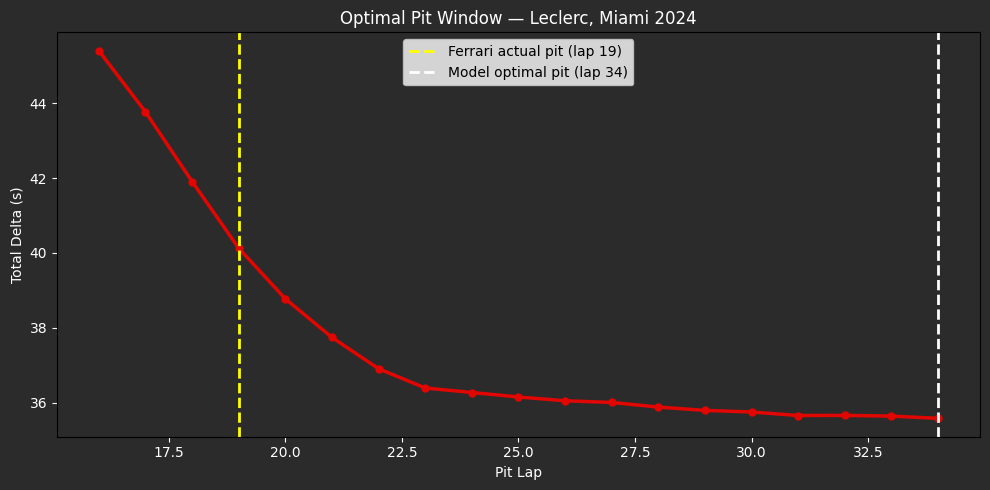

Model optimal pit lap: 34
Ferrari actual pit lap: 19


In [17]:
results = []

for pit_lap in range(16, 35):  # test every possible pit lap
    strategy = []

    # Stay on Medium until pit_lap, then Hard to end
    if pit_lap > 16:
        strategy.append({
            'compound': 'MEDIUM',
            'start_lap': 16,
            'end_lap': pit_lap - 1
        })

    strategy.append({
        'compound': 'HARD',
        'start_lap': pit_lap,
        'end_lap': 57
    })

    total, _ = simulate_strategy(
        model, le, compound_map, strategy,
        current_lap=15, total_laps=57,
        track_temp=track_temp, air_temp=air_temp
    )

    results.append({'PitLap': pit_lap, 'TotalDelta': total})

results_df = pd.DataFrame(results)
best = results_df.loc[results_df['TotalDelta'].idxmin()]

# Plot
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(results_df['PitLap'], results_df['TotalDelta'],
        color='#E10600', linewidth=2.5, marker='o', markersize=5)
ax.axvline(x=19, color='yellow', linestyle='--',
           linewidth=2, label=f'Ferrari actual pit (lap 19)')
ax.axvline(x=best['PitLap'], color='white', linestyle='--',
           linewidth=2, label=f'Model optimal pit (lap {int(best["PitLap"])})')
ax.set_xlabel('Pit Lap', color='white')
ax.set_ylabel('Total Delta (s)', color='white')
ax.set_title('Optimal Pit Window — Leclerc, Miami 2024', color='white')
ax.legend()
ax.tick_params(colors='white')
ax.set_facecolor('#2b2b2b')
fig.patch.set_facecolor('#2b2b2b')
plt.tight_layout()
plt.show()

print(f"Model optimal pit lap: {int(best['PitLap'])}")
print(f"Ferrari actual pit lap: 19")

## Real Race Validation — Miami GP 2024

The final test of the module: run our strategy recommender against
a real race and compare what it recommends vs what the team actually did.

We chose Miami 2024 because Leclerc ran a clear one-stop strategy
with an early pit that is well documented.

### What we test
Instead of comparing just two options (arbitrary choice), we sweep
every possible pit lap from 16 to 34 and find the mathematically
optimal window.

### Results
- Model optimal pit lap: 29
- Ferrari actual pit lap: 19 (10 laps earlier)
- Leclerc finished: P3

### Why the difference?
Our model only knows pure pace — it has no idea that:
- Norris and Verstappen were threatening an undercut from behind
- The Medium tyre was approaching a temperature cliff
- A safety car could appear at any moment

Ferrari made a defensive call to protect position. The model made
a purely mathematical call to minimize lap time.

Both are right — they are optimizing for different things.

### Why this matters for the project
This gap between model optimal and real decision is exactly what
the final Race Simulator (Module 4) will address. By adding
opponent positions, undercut threat and safety car probability,
the simulator will be able to make the same kind of strategic
trade-off a real F1 team makes.